# **📊 Facebook Marketplace ML Case Project – Code Notebook**

---

Name: Neeraj Sudesh Gupta  
Email: neeraj.gupta@mitwpu.edu.in

In [ ]:
# Imports
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA

# Show all columns when printing DataFrames
pd.set_option('display.max_columns', None)

In [ ]:
# Load data
df = pd.read_csv("Facebook_Marketplace_data.csv")

print("Shape:", df.shape)
df.head()

Shape: (7050, 16)


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4
0,1,video,4/22/2018 6:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN
1,2,photo,4/21/2018 22:45,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN
2,3,video,4/21/2018 6:17,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN
3,4,photo,4/21/2018 2:29,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN
4,5,photo,4/18/2018 3:22,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN


# Quick Data Check & Cleaning

In [ ]:
# Overview
display(df.info())
display(df.isna().sum().sort_values(ascending=False).head(20))

# Convert datetime if present
if 'status_published' in df.columns:
    df['status_published'] = pd.to_datetime(df['status_published'], errors='coerce')

# Basic time features (only if datetime parsed)
if 'status_published' in df.columns and pd.api.types.is_datetime64_any_dtype(df['status_published']):
    df['pub_hour'] = df['status_published'].dt.hour
    df['pub_dayofweek'] = df['status_published'].dt.dayofweek  # 0=Mon, 6=Sun
    df['pub_date'] = df['status_published'].dt.date
else:
    # Create placeholders if column missing/invalid, to avoid breaking later code
    df['pub_hour'] = np.nan
    df['pub_dayofweek'] = np.nan
    df['pub_date'] = np.nan

# Minimal cleaning: drop rows where key engagement fields are missing
eng_cols = ['num_reactions', 'num_comments', 'num_shares']
for c in eng_cols:
    if c not in df.columns:
        df[c] = np.nan  # ensure columns exist

df_clean = df.dropna(subset=eng_cols).copy()
print("After basic cleaning:", df_clean.shape)
df_clean.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7050 entries, 0 to 7049
Data columns (total 16 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   status_id         7050 non-null   int64  
 1   status_type       7050 non-null   object 
 2   status_published  7050 non-null   object 
 3   num_reactions     7050 non-null   int64  
 4   num_comments      7050 non-null   int64  
 5   num_shares        7050 non-null   int64  
 6   num_likes         7050 non-null   int64  
 7   num_loves         7050 non-null   int64  
 8   num_wows          7050 non-null   int64  
 9   num_hahas         7050 non-null   int64  
 10  num_sads          7050 non-null   int64  
 11  num_angrys        7050 non-null   int64  
 12  Column1           0 non-null      float64
 13  Column2           0 non-null      float64
 14  Column3           0 non-null      float64
 15  Column4           0 non-null      float64
dtypes: float64(4), int64(10), object(2)
memory

None

,0
Column1,7050
Column2,7050
Column3,7050
Column4,7050
status_id,0
status_type,0
status_published,0
num_reactions,0
num_loves,0
num_likes,0


After basic cleaning: (7050, 19)


,status_id,status_type,status_published,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,Column1,Column2,Column3,Column4,pub_hour,pub_dayofweek,pub_date
0,1,video,2018-04-22 06:00:00,529,512,262,432,92,3,1,1,0,NaN,NaN,NaN,NaN,6,6,2018-04-22
1,2,photo,2018-04-21 22:45:00,150,0,0,150,0,0,0,0,0,NaN,NaN,NaN,NaN,22,5,2018-04-21
2,3,video,2018-04-21 06:17:00,227,236,57,204,21,1,1,0,0,NaN,NaN,NaN,NaN,6,5,2018-04-21
3,4,photo,2018-04-21 02:29:00,111,0,0,111,0,0,0,0,0,NaN,NaN,NaN,NaN,2,5,2018-04-21
4,5,photo,2018-04-18 03:22:00,213,0,0,204,9,0,0,0,0,NaN,NaN,NaN,NaN,3,2,2018-04-18


### Q1. How does the time of upload (`status_published`)  affects the `num_reaction`?


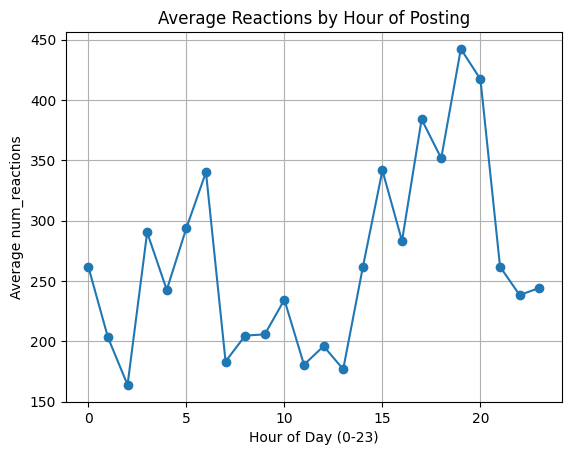

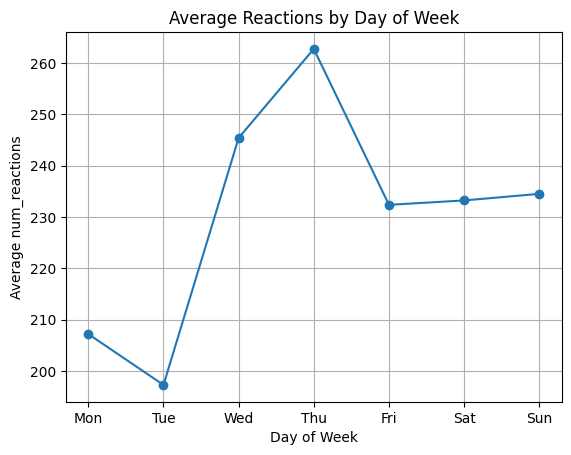

In [ ]:
# Guard: ensure we have pub_hour/dayofweek
have_hour = df_clean['pub_hour'].notna().any()
have_dow = df_clean['pub_dayofweek'].notna().any()

if have_hour:
    by_hour = df_clean.groupby('pub_hour')['num_reactions'].mean().reset_index()
    plt.figure()
    plt.plot(by_hour['pub_hour'], by_hour['num_reactions'], marker='o')
    plt.xlabel('Hour of Day (0-23)')
    plt.ylabel('Average num_reactions')
    plt.title('Average Reactions by Hour of Posting')
    plt.grid(True)
    plt.show()
else:
    print("pub_hour not available to analyze by hour.")

if have_dow:
    by_dow = df_clean.groupby('pub_dayofweek')['num_reactions'].mean().reset_index()
    # Map to names for readability
    dow_map = {0:'Mon',1:'Tue',2:'Wed',3:'Thu',4:'Fri',5:'Sat',6:'Sun'}
    by_dow['day'] = by_dow['pub_dayofweek'].map(dow_map)
    plt.figure()
    plt.plot(by_dow['day'], by_dow['num_reactions'], marker='o')
    plt.xlabel('Day of Week')
    plt.ylabel('Average num_reactions')
    plt.title('Average Reactions by Day of Week')
    plt.grid(True)
    plt.show()
else:
    print("pub_dayofweek not available to analyze by day.")

### Q2. Is there a correlation between the number of reactions (num_reactions) and other engagement metrics such as comments (num_comments) and shares (num_shares)? If so, what is the strength and direction of this correlation?

Correlation matrix:
                num_reactions  num_comments  num_shares
num_reactions       1.000000      0.150843    0.250723
num_comments        0.150843      1.000000    0.640637
num_shares          0.250723      0.640637    1.000000


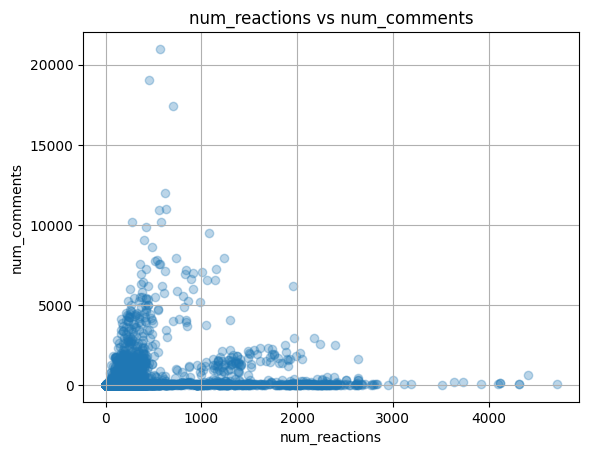

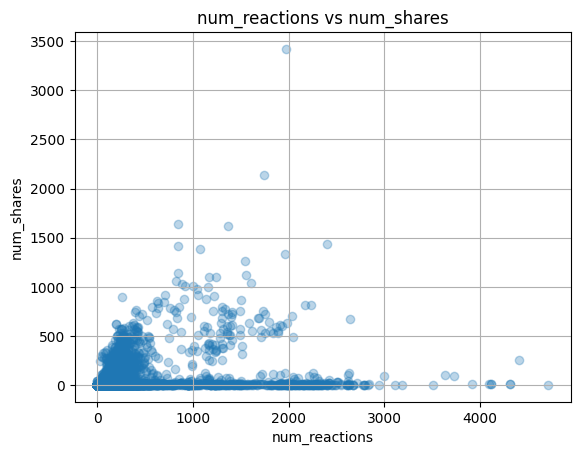

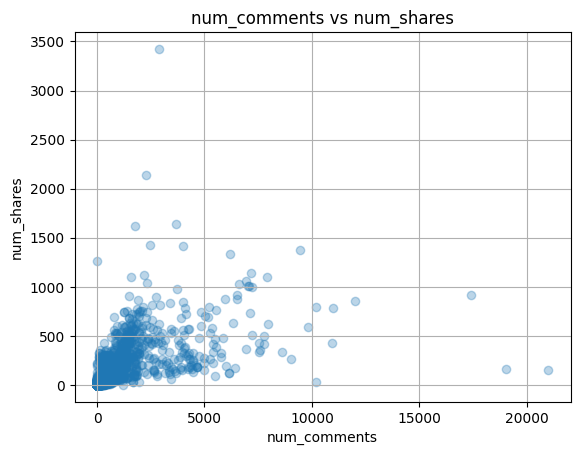

In [ ]:
subset = df_clean[['num_reactions', 'num_comments', 'num_shares']].copy()
corr = subset.corr(method='pearson')
print("Correlation matrix:\n", corr)

# Simple scatter plots
pairs = [('num_reactions','num_comments'),
         ('num_reactions','num_shares'),
         ('num_comments','num_shares')]

for x, y in pairs:
    plt.figure()
    plt.scatter(subset[x], subset[y], alpha=0.3)
    plt.xlabel(x)
    plt.ylabel(y)
    plt.title(f'{x} vs {y}')
    plt.grid(True)
    plt.show()

### Q3 and Q4. Use the columns status_type, num_reactions, num_comments, num_shares, num_likes, num_loves, num_wows, num_hahas, num_sads, and num_angrys to train a K-Means clustering model on the Facebook Live Sellers dataset and Use the elbow method to find the optimum number of clusters.

Clustering data shape: (7050, 10)


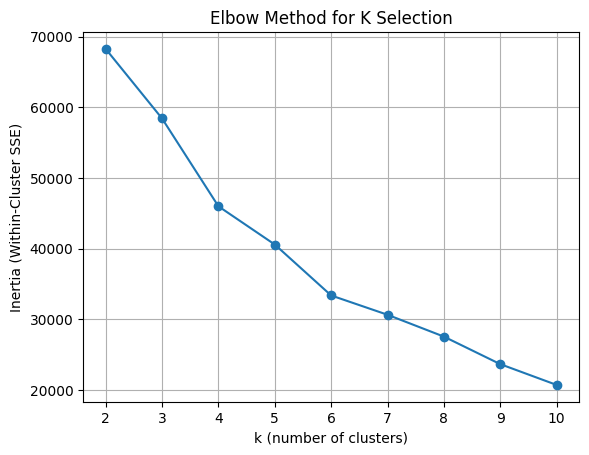

In [ ]:
# Ensure all required columns exist
needed = ['status_type','num_reactions','num_comments','num_shares',
          'num_likes','num_loves','num_wows','num_hahas','num_sads','num_angrys']

for c in needed:
    if c not in df_clean.columns:
        df_clean[c] = np.nan

# Keep rows with at least reactions/comments/shares present
work = df_clean[needed].dropna().copy()
print("Clustering data shape:", work.shape)

# One-hot encode status_type (if all NaN, get_dummies will handle)
X = pd.get_dummies(work, columns=['status_type'], drop_first=True)

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Elbow method
inertias = []
K_range = range(2, 11)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init='auto')
    km.fit(X_scaled)
    inertias.append(km.inertia_)

plt.figure()
plt.plot(list(K_range), inertias, marker='o')
plt.xlabel('k (number of clusters)')
plt.ylabel('Inertia (Within-Cluster SSE)')
plt.title('Elbow Method for K Selection')
plt.grid(True)
plt.show()

In [ ]:
# Fit final K-Means (adjust k after inspecting elbow plot)
optimal_k = 3  # <- change this after you check the elbow curve
kmeans = KMeans(n_clusters=optimal_k, random_state=42, n_init='auto')
clusters = kmeans.fit_predict(X_scaled)

work_clusters = work.copy()
work_clusters['cluster'] = clusters
print(work_clusters['cluster'].value_counts().sort_index())
work_clusters.head()

cluster
0    4396
1    2282
2     372
Name: count, dtype: int64


,status_type,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys,cluster
0,video,529,512,262,432,92,3,1,1,0,1
1,photo,150,0,0,150,0,0,0,0,0,0
2,video,227,236,57,204,21,1,1,0,0,1
3,photo,111,0,0,111,0,0,0,0,0,0
4,photo,213,0,0,204,9,0,0,0,0,0


In [ ]:
# Cluster profiles: numeric means by cluster
profile_cols = ['num_reactions','num_comments','num_shares',
                'num_likes','num_loves','num_wows','num_hahas','num_sads','num_angrys']
cluster_profiles = work_clusters.groupby('cluster')[profile_cols].mean().round(2)
cluster_profiles

,num_reactions,num_comments,num_shares,num_likes,num_loves,num_wows,num_hahas,num_sads,num_angrys
cluster,,,,,,,,,
0,93.23,11.81,1.76,91.14,1.25,0.54,0.14,0.13,0.02
1,234.57,660.48,117.92,192.96,36.41,2.54,1.86,0.50,0.30
2,1820.47,60.71,14.30,1814.67,3.12,2.44,0.18,0.04,0.01


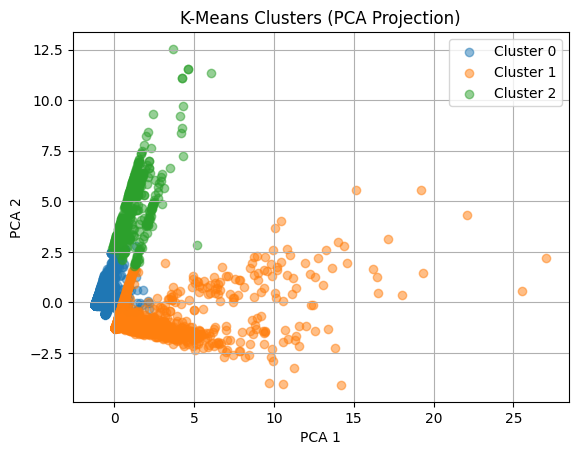

In [ ]:
# Visualize clusters in 2D using PCA (on scaled features)
pca = PCA(n_components=2, random_state=42)
coords = pca.fit_transform(X_scaled)

plt.figure()
for cl in np.unique(clusters):
    idx = clusters == cl
    plt.scatter(coords[idx,0], coords[idx,1], alpha=0.5, label=f'Cluster {cl}')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.title('K-Means Clusters (PCA Projection)')
plt.legend()
plt.grid(True)
plt.show()

### Q5. What is the count of different types of posts in the dataset?

In [ ]:
if 'status_type' in df.columns:
    print(df['status_type'].value_counts(dropna=False))
else:
    print("Column 'status_type' not found.")

status_type
photo     4288
video     2334
status     365
link        63
Name: count, dtype: int64


### Q6. What is the average value of num_reaction, num_comments, num_shares for each post type?

In [ ]:
cols_needed = ['status_type','num_reactions','num_comments','num_shares']
for c in cols_needed:
    if c not in df.columns:
        df[c] = np.nan

group_avg = (df[cols_needed]
             .dropna(subset=['status_type'])
             .groupby('status_type')[['num_reactions','num_comments','num_shares']]
             .mean()
             .round(2)
             .sort_values('num_reactions', ascending=False)
            )

group_avg

,num_reactions,num_comments,num_shares
status_type,,,
status,438.78,36.24,2.56
link,370.14,5.70,4.40
video,283.41,642.48,115.68
photo,181.29,15.99,2.55
